In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\shrut\Documents\credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.shape

(32581, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df.fillna(df.median(numeric_only=True),inplace=True)

In [8]:
df.drop_duplicates(inplace=True)

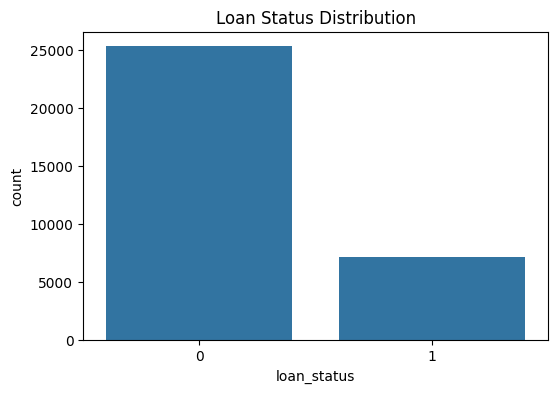

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='loan_status',
    data=df
)

plt.title('Loan Status Distribution')
plt.show()

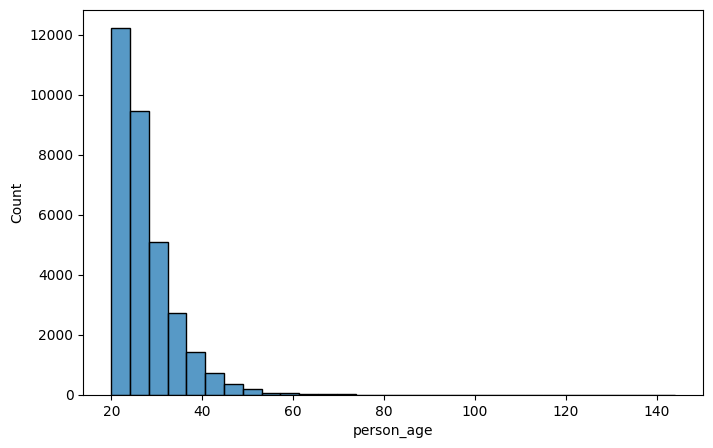

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['person_age'],
    bins=30
)

plt.show()

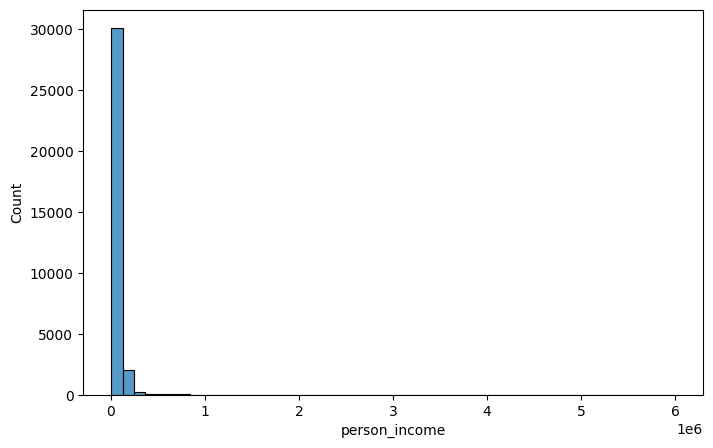

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['person_income'],
    bins=50
)

plt.show()

<Axes: xlabel='loan_amnt', ylabel='Count'>

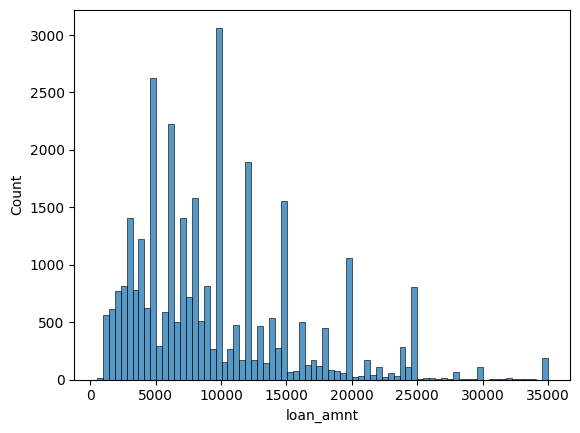

In [12]:
sns.histplot(df['loan_amnt'])

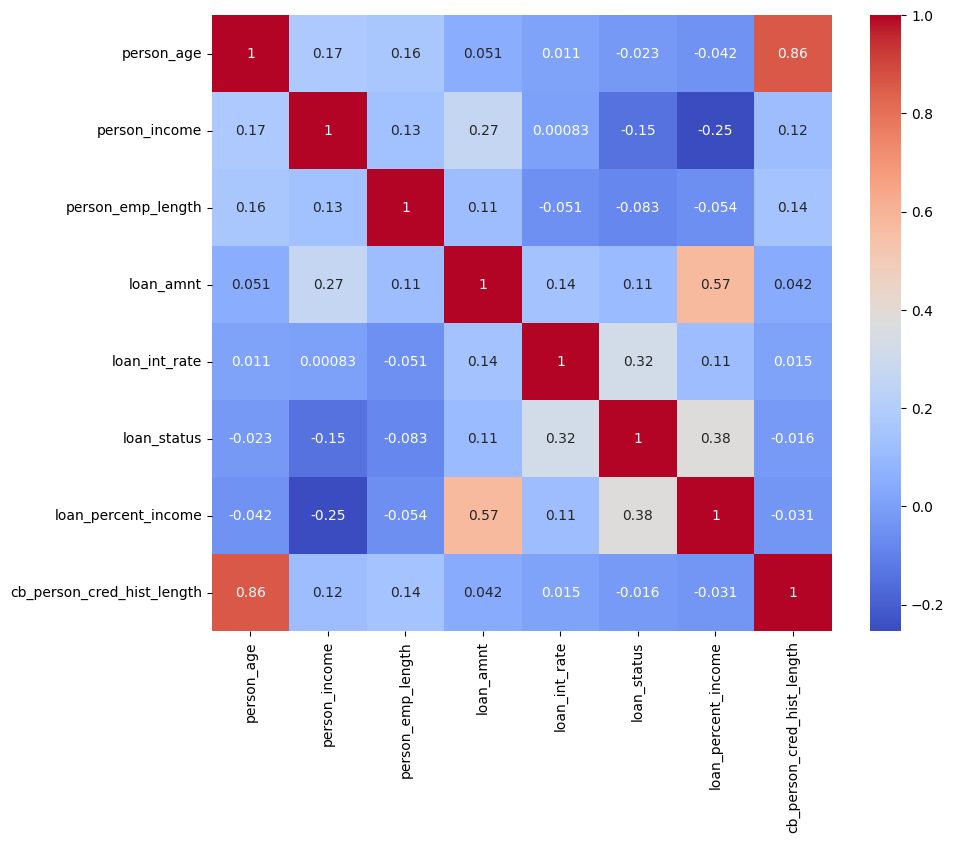

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

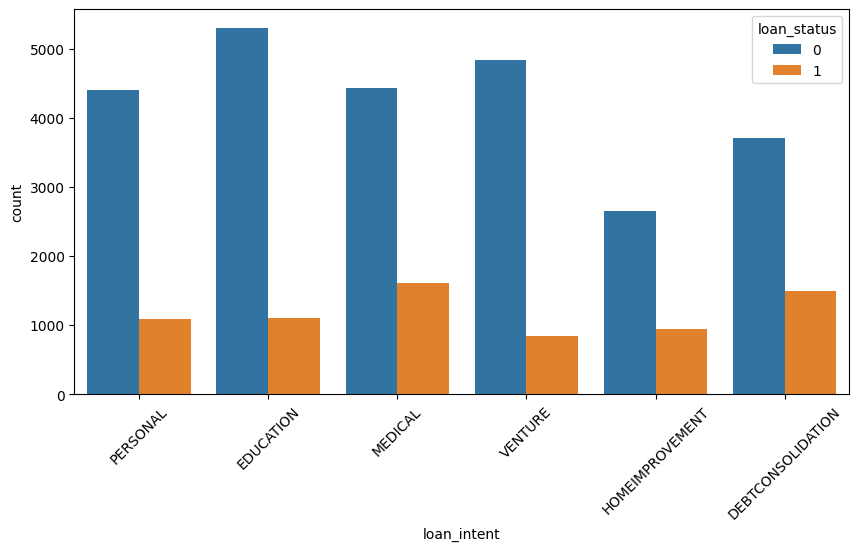

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='loan_intent',
    hue='loan_status',
    data=df
)

plt.xticks(rotation=45)

plt.show()

<Axes: xlabel='person_home_ownership', ylabel='count'>

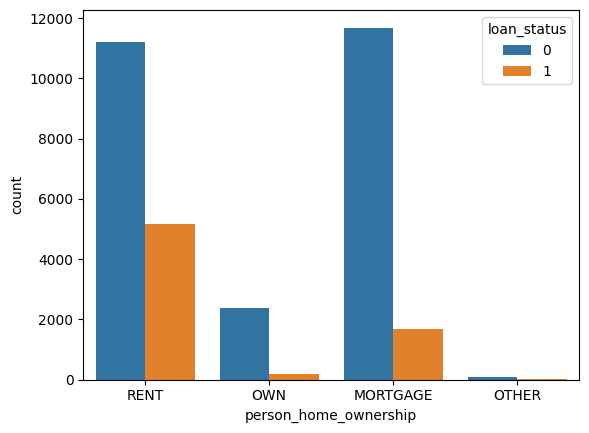

In [15]:
sns.countplot(
    x='person_home_ownership',
    hue='loan_status',
    data=df
)

<Axes: xlabel='person_income'>

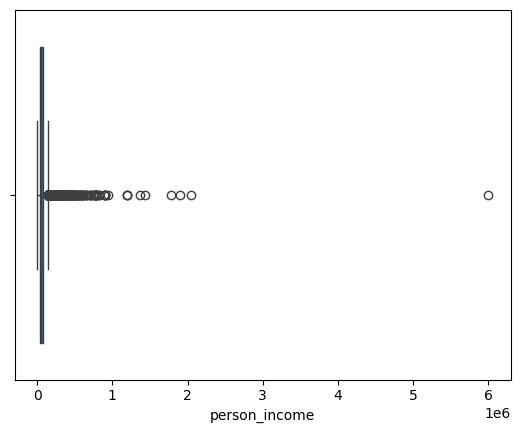

In [16]:
sns.boxplot(
    x=df['person_income']
)

In [17]:
df['dti_ratio'] = (
    df['loan_amnt']
    /
    df['person_income']
)

In [18]:
df['interest_burden'] = (
    df['loan_int_rate']
    *
    df['loan_amnt']
)

In [19]:
df['age_group'] = pd.cut(
    df['person_age'],
    bins=[20,30,40,50,60,100],
    labels=[
        '20-30',
        '30-40',
        '40-50',
        '50-60',
        '60+'
    ]
)

In [20]:
df['income_group'] = pd.qcut(
     df['person_income'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [21]:
import os
os.makedirs('data', exist_ok=True)

os.listdir()

['.anaconda',
 '.conda',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '01_EDA_Feature_Engineering.ipynb',
 '02_Model_Training.ipynb',
 '03_Advanced_Analytics.ipynb',
 'anaconda3',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'data',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'final_xgboost_model.pkl',
 'Links',
 'Local Settings',
 'Microsoft',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{f2534b45-e8b5-11f0-baf8-ec91619a9c68}.TM.blf',
 'NTUSER.DAT{f2534b45-e8b5-11f0-baf8-ec91619a9c68}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{f2534b45-e8b5-11f0-baf8-ec91619a9c68}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pictures',
 'PrintHood',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'Untitled.ipynb',
 'Untitled1.ipynb',
 'Videos',
 'xgboost_model.pkl']

In [22]:
df.to_csv(
    'data/processed_credit_data.csv',
    index=False
)

In [23]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,dti_ratio,interest_burden,age_group,income_group
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,0.593220,560700.0,20-30,High
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,11140.0,20-30,Low
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,70785.0,20-30,Low
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,533050.0,20-30,High
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,499450.0,20-30,Medium


In [25]:
df['loan_status'].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64